### Importación de datos



In [ ]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tienda.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


#1. Análisis de facturación



In [ ]:
# Cálculo del ingreso total por tienda
ingreso_tienda = tienda['Precio'].sum()
ingreso_tienda2 = tienda2['Precio'].sum()
ingreso_tienda3 = tienda3['Precio'].sum()
ingreso_tienda4 = tienda4['Precio'].sum()

# Mostrar los resultados
print("---Análisis de Facturación Total por Tiendas---")
print(f"Ingreso total de la Tienda 1: ${ingreso_tienda:,.2f}")
print(f"Ingreso total de la Tienda 2: ${ingreso_tienda2:,.2f}")
print(f"Ingreso total de la Tienda 3: ${ingreso_tienda3:,.2f}")
print(f"Ingreso total de la Tienda 4: ${ingreso_tienda4:,.2f}")

---Análisis de Facturación Total por Tiendas---
Ingreso total de la Tienda 1: $1,150,880,400.00
Ingreso total de la Tienda 2: $1,116,343,500.00
Ingreso total de la Tienda 3: $1,098,019,600.00
Ingreso total de la Tienda 4: $1,038,375,700.00


# 2. Ventas por categoría

In [88]:
import pandas as pd

# URLs de los archivos CSV
urls = {
    "Tienda 1": "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv",
    "Tienda 2": "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv",
    "Tienda 3": "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv",
    "Tienda 4": "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"
}

for nombre, url in urls.items():
    try:
        df = pd.read_csv(url)
        df.columns = df.columns.str.strip()

        # 1. Ventas (Cant)
        ventas = df['Categoría del Producto'].value_counts()

        # 2. Popularidad (%)
        popularidad = (df['Categoría del Producto'].value_counts(normalize=True) * 100).round(2)

        # 3. Ingresos Totales ($)
        ingresos = df.groupby('Categoría del Producto')['Precio'].sum().sort_values(ascending=False)
        # Formateamos los ingresos como moneda para que se vean bien en la tabla
        ingresos_totales = ingresos.map('${:,.2f}'.format)

        # --- SALIDA CON FORMATO UNIFICADO ---
        print(f"=== Análisis de Categorías: {nombre} ===\n")

        print(f"Categoría del Producto      Ventas (Cantidad)")
        print(ventas.to_string(header=False))

        print(f"\nCategoría del Producto      Popularidad (%)")
        print(popularidad.to_string(header=False))

        print(f"\nCategoría del Producto      Ingresos Totales ($)")
        print(ingresos_totales.to_string(header=False))

        print("\n" + "-"*55 + "\n")

    except Exception as e:
        print(f"No se pudo procesar {nombre}: {e}")

=== Análisis de Categorías: Tienda 1 ===

Categoría del Producto      Ventas (Cantidad)
Muebles                    465
Electrónicos               448
Juguetes                   324
Electrodomésticos          312
Deportes y diversión       284
Instrumentos musicales     182
Libros                     173
Artículos para el hogar    171

Categoría del Producto      Popularidad (%)
Muebles                    19.71
Electrónicos               18.99
Juguetes                   13.73
Electrodomésticos          13.23
Deportes y diversión       12.04
Instrumentos musicales      7.72
Libros                      7.33
Artículos para el hogar     7.25

Categoría del Producto      Ingresos Totales ($)
Electrónicos               $429,493,500.00
Electrodomésticos          $363,685,200.00
Muebles                    $187,633,700.00
Instrumentos musicales      $91,299,000.00
Deportes y diversión        $39,290,000.00
Juguetes                    $17,995,700.00
Artículos para el hogar     $12,698,400.00
Libr

# 3. Calificación promedio de la tienda


In [89]:
import pandas as pd

# URLs de los archivos CSV
urls = {
    "Tienda 1": "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv",
    "Tienda 2": "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv",
    "Tienda 3": "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv",
    "Tienda 4": "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"
}

print("=== ANÁLISIS DE SATISFACCIÓN DEL CLIENTE ===\n")

for nombre, url in urls.items():
    try:
        df = pd.read_csv(url)
        # Limpieza de nombres de columnas para evitar errores de espacios
        df.columns = df.columns.str.strip()

        # Cálculo de la calificación promedio
        promedio_calificacion = df['Calificación'].mean()

        # Mostrar el resultado con 2 decimales
        print(f"La calificación promedio en {nombre} es: {promedio_calificacion:.2f} puntos")

    except Exception as e:
        print(f"No se pudo procesar {nombre}: {e}")

print("\n" + "-"*40)

=== ANÁLISIS DE SATISFACCIÓN DEL CLIENTE ===

La calificación promedio en Tienda 1 es: 3.98 puntos
La calificación promedio en Tienda 2 es: 4.04 puntos
La calificación promedio en Tienda 3 es: 4.05 puntos
La calificación promedio en Tienda 4 es: 4.00 puntos

----------------------------------------


# 4. Productos más y menos vendidos

In [ ]:
import pandas as pd

# URLs de los archivos CSV
urls = {
    "Tienda 1": "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv",
    "Tienda 2": "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv",
    "Tienda 3": "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv",
    "Tienda 4": "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"
}

for nombre, url in urls.items():
    try:
        df = pd.read_csv(url)
        df.columns = df.columns.str.strip()

        # Conteo de ventas por nombre de producto
        ventas_por_producto = df['Producto'].value_counts()

        # Identificar el más y el menos vendido
        mas_vendido = ventas_por_producto.idxmax()
        cant_mas = ventas_por_producto.max()

        menos_vendido = ventas_por_producto.idxmin()
        cant_menos = ventas_por_producto.min()

        # --- IMPRESIÓN DE RESULTADOS ---
        print(f"=== ANÁLISIS DE PRODUCTOS: {nombre} ===")
        print(f"Producto MÁS VENDIDO: {mas_vendido} ({cant_mas} unidades)")
        print(f"Producto MENOS VENDIDO: {menos_vendido} ({cant_menos} unidades)")
        print("-" * 50 + "\n")

    except Exception as e:
        print(f"No se pudo procesar {nombre}: {e}")

=== ANÁLISIS DE PRODUCTOS: Tienda 1 ===
Producto MÁS VENDIDO: Microondas (60 unidades)
Producto MENOS VENDIDO: Auriculares con micrófono (33 unidades)
--------------------------------------------------

=== ANÁLISIS DE PRODUCTOS: Tienda 2 ===
Producto MÁS VENDIDO: Iniciando en programación (65 unidades)
Producto MENOS VENDIDO: Juego de mesa (32 unidades)
--------------------------------------------------

=== ANÁLISIS DE PRODUCTOS: Tienda 3 ===
Producto MÁS VENDIDO: Kit de bancas (57 unidades)
Producto MENOS VENDIDO: Bloques de construcción (35 unidades)
--------------------------------------------------

=== ANÁLISIS DE PRODUCTOS: Tienda 4 ===
Producto MÁS VENDIDO: Cama box (62 unidades)
Producto MENOS VENDIDO: Guitarra eléctrica (33 unidades)
--------------------------------------------------



# 5. Envío promedio por tienda

In [ ]:
import pandas as pd

# URLs de los archivos CSV
urls = {
    "Tienda 1": "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv",
    "Tienda 2": "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv",
    "Tienda 3": "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv",
    "Tienda 4": "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"
}

print("=== ANÁLISIS DE COSTOS DE ENVÍO PROMEDIO ===\n")

for nombre, url in urls.items():
    try:
        # Cargar datos
        df = pd.read_csv(url)

        # Limpiar nombres de columnas
        df.columns = df.columns.str.strip()

        # Calcular el promedio de la columna 'Costo de Envío'
        promedio_envio = df['Costo de envío'].mean()

        # Mostrar el resultado con formato de moneda
        print(f"El costo de envío promedio en {nombre} es: ${promedio_envio:,.2f}")

    except Exception as e:
        print(f"No se pudo procesar {nombre}: {e}")

print("\n" + "-"*45)

=== ANÁLISIS DE COSTOS DE ENVÍO PROMEDIO ===

El costo de envío promedio en Tienda 1 es: $26,018.61
El costo de envío promedio en Tienda 2 es: $25,216.24
El costo de envío promedio en Tienda 3 es: $24,805.68
El costo de envío promedio en Tienda 4 es: $23,459.46

---------------------------------------------


# 6. Generación y Visualización de Gráficos

###1. Análisis de Facturación (Ingresos Totales)

Este gráfico de barras compara el dinero total recaudado. Es fundamental para ver qué unidad de negocio es la más rentable financieramente.

/tmp/ipython-input-791/2362029065.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=nombres, y=ingresos, palette='viridis')


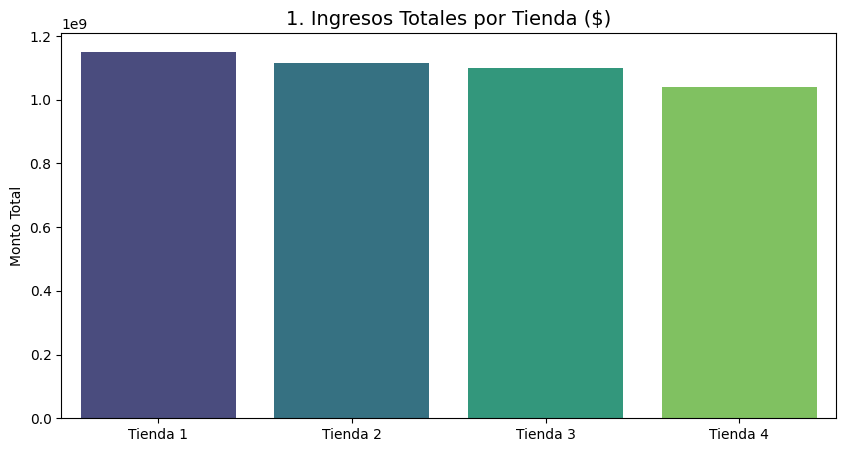

In [104]:
import matplotlib.pyplot as plt
import seaborn as sns

# Cálculo de ingresos
ingresos = [tienda['Precio'].sum(), tienda2['Precio'].sum(), tienda3['Precio'].sum(), tienda4['Precio'].sum()]
nombres = ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4']

plt.figure(figsize=(10, 5))
sns.barplot(x=nombres, y=ingresos, palette='viridis')
plt.title('1. Ingresos Totales por Tienda ($)', fontsize=14)
plt.ylabel('Monto Total')
plt.show()

###2. Categorías de Productos (Distribución de Ventas)

Utilizamos gráficos de pastel para ver el "Mix de Productos". Esto revela si una tienda depende de una sola categoría o si tiene ventas diversificadas.

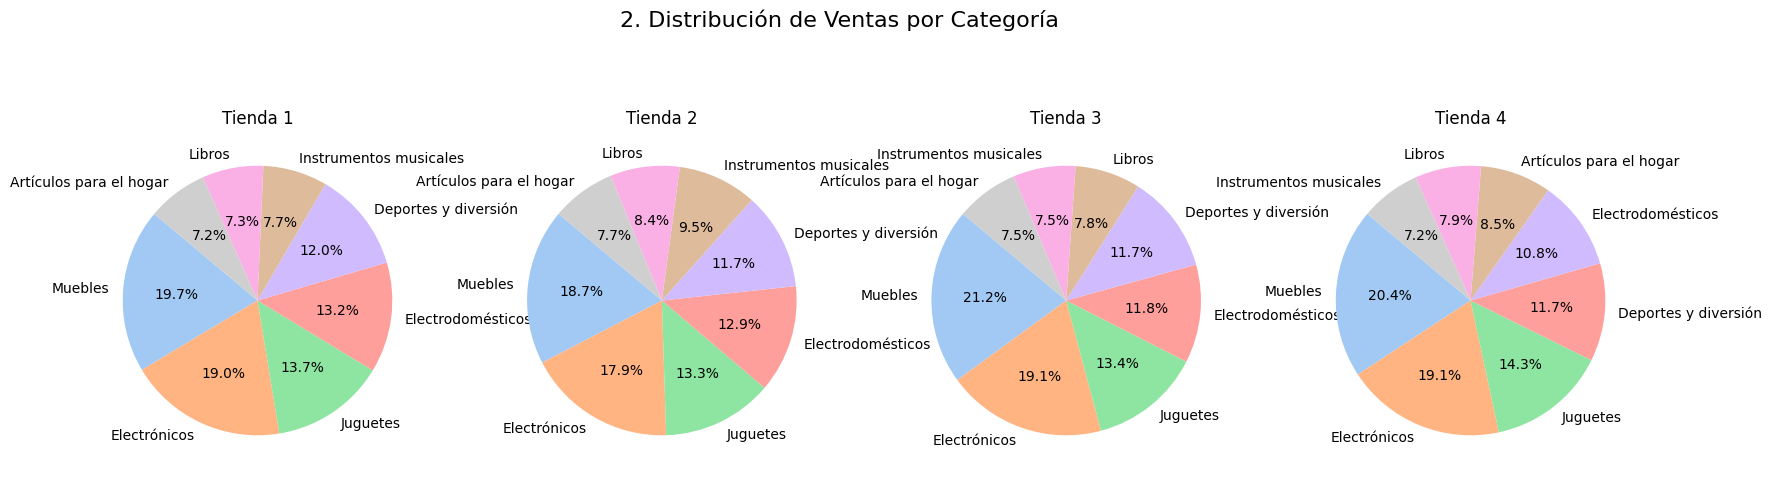

In [105]:
fig, axes = plt.subplots(1, 4, figsize=(20, 6))
tiendas_list = [tienda, tienda2, tienda3, tienda4]

for i, df in enumerate(tiendas_list):
    data = df['Categoría del Producto'].value_counts()
    axes[i].pie(data, labels=data.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
    axes[i].set_title(f'Tienda {i+1}')

plt.suptitle('2. Distribución de Ventas por Categoría', fontsize=16)
plt.show()


###3. Calificaciones Promedio (Satisfacción)
El gráfico de líneas (o puntos) permite comparar el nivel de felicidad del cliente. Una caída en esta línea indica problemas graves en el servicio o calidad del producto.

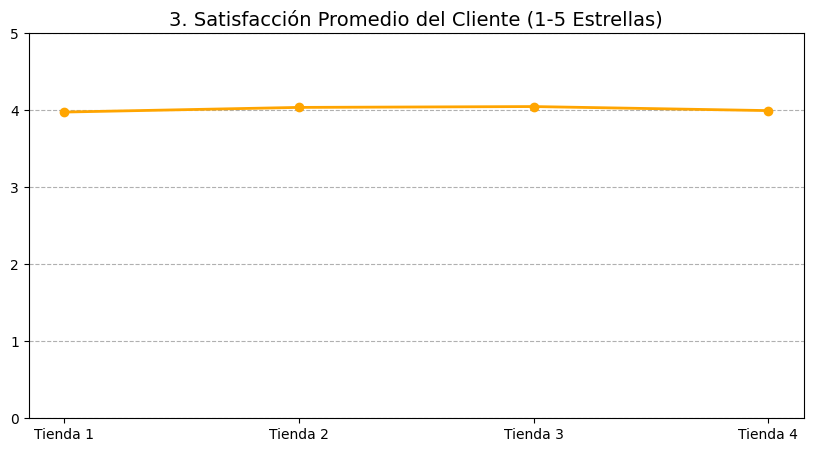

In [107]:
# Promedios de calificación
puntuaciones = [tienda['Calificación'].mean(), tienda2['Calificación'].mean(),
                tienda3['Calificación'].mean(), tienda4['Calificación'].mean()]

plt.figure(figsize=(10, 5))
plt.plot(nombres, puntuaciones, marker='o', linestyle='-', color='orange', linewidth=2)
plt.ylim(0, 5) # Escala de 1 a 5 estrellas
plt.title('3. Satisfacción Promedio del Cliente (1-5 Estrellas)', fontsize=14)
plt.grid(axis='y', linestyle='--')
plt.show()

###4. Productos Estrella vs. Menos Vendidos (Ingresos)

Aquí graficamos el Top 5 de productos que más dinero generan por cada tienda comparado con los que menos aportan.

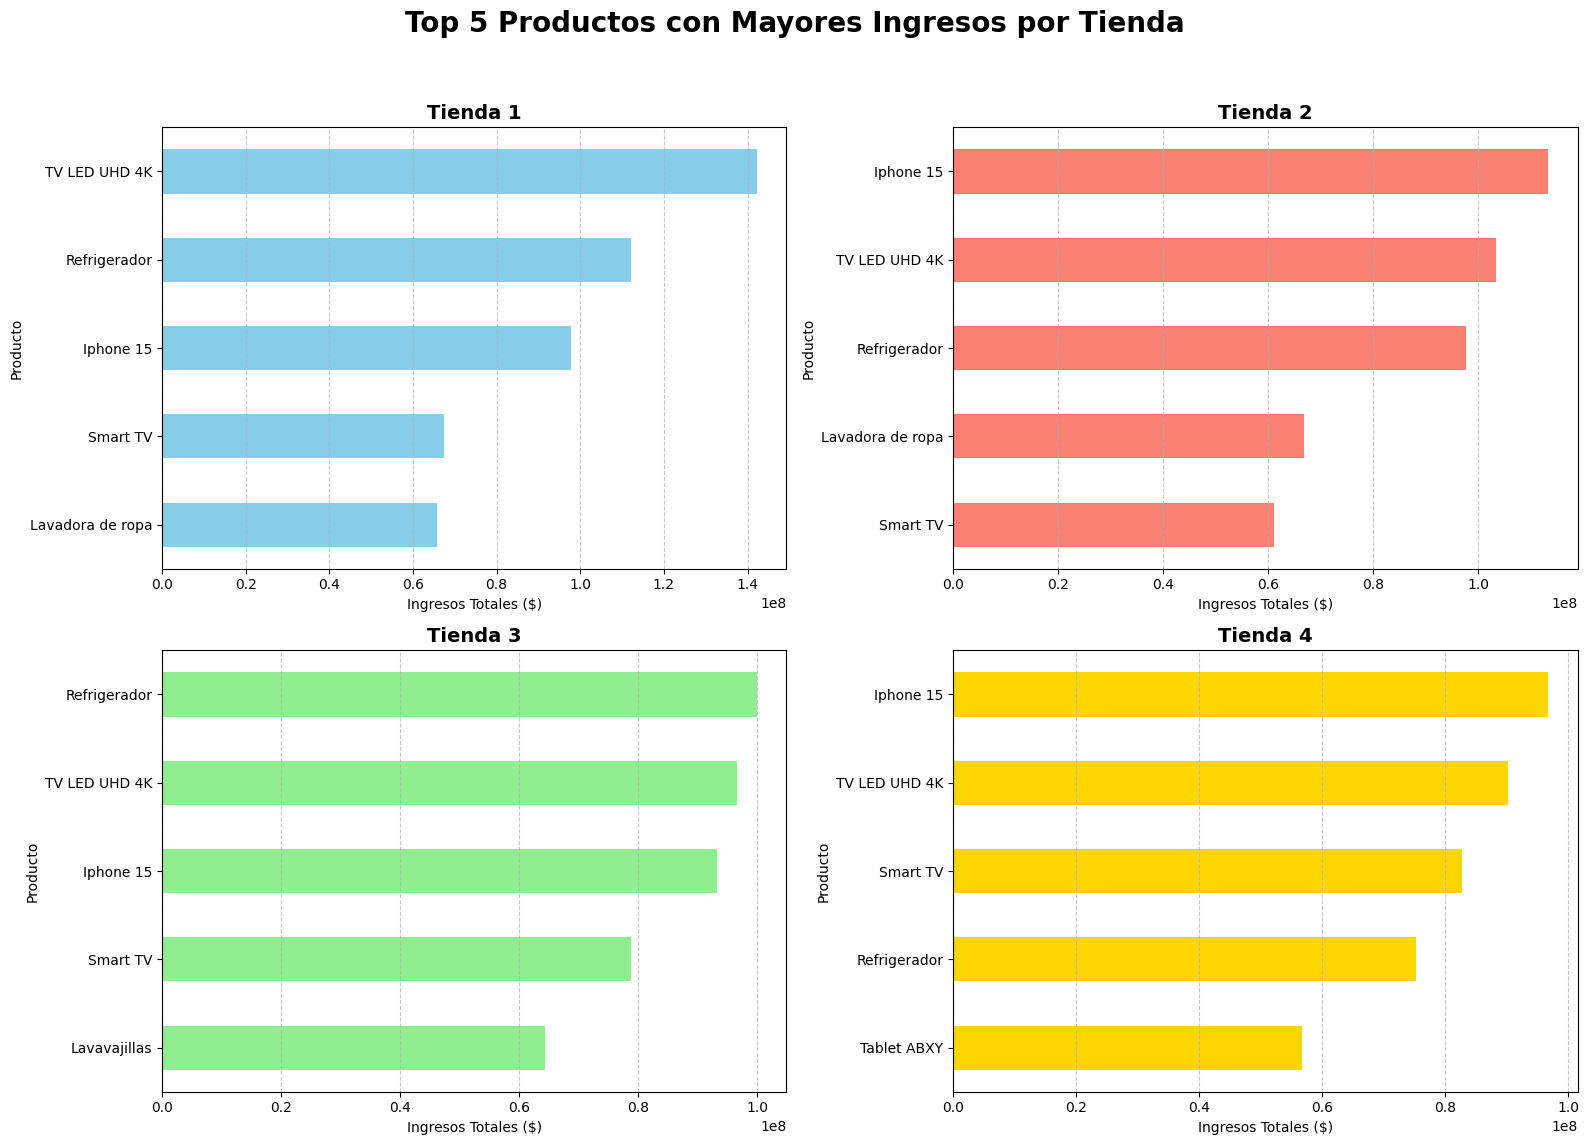

In [111]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Configurar la cuadrícula de 2x2
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Top 5 Productos con Mayores Ingresos por Tienda', fontsize=20, fontweight='bold')

# Lista de DataFrames y sus nombres
tiendas_list = [tienda, tienda2, tienda3, tienda4]
nombres_tiendas = ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4']
colores = ['skyblue', 'salmon', 'lightgreen', 'gold']

# 2. Iterar para crear los 4 gráficos
for i, ax in enumerate(axes.flat):
    df_actual = tiendas_list[i]
    df_actual.columns = df_actual.columns.str.strip()

    # Calcular Top 5 por ingresos (Suma de Precio por Producto)
    # Nota: Asegúrate de que la columna se llame 'Producto' o 'Nombre del Producto'
    top_5 = df_actual.groupby('Producto')['Precio'].sum().sort_values(ascending=False).head(5)

    # Crear gráfico de barras horizontales
    top_5.plot(kind='barh', ax=ax, color=colores[i])

    # Configuración de cada subgráfico
    ax.set_title(f'{nombres_tiendas[i]}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Ingresos Totales ($)', fontsize=10)
    ax.set_ylabel('Producto', fontsize=10)
    ax.invert_yaxis()  # El producto con más ingresos aparece arriba
    ax.grid(axis='x', linestyle='--', alpha=0.7)

# Ajustar diseño para evitar solapamientos
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

###5. Costo de Envío Promedio (Gasto del Cliente)

Este gráfico comparativo muestra qué tan "cara" es la logística de cada tienda. Si el envío es muy alto, los clientes abandonarán el carrito.

/tmp/ipython-input-791/371354327.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=nombres, y=envios, palette='coolwarm')


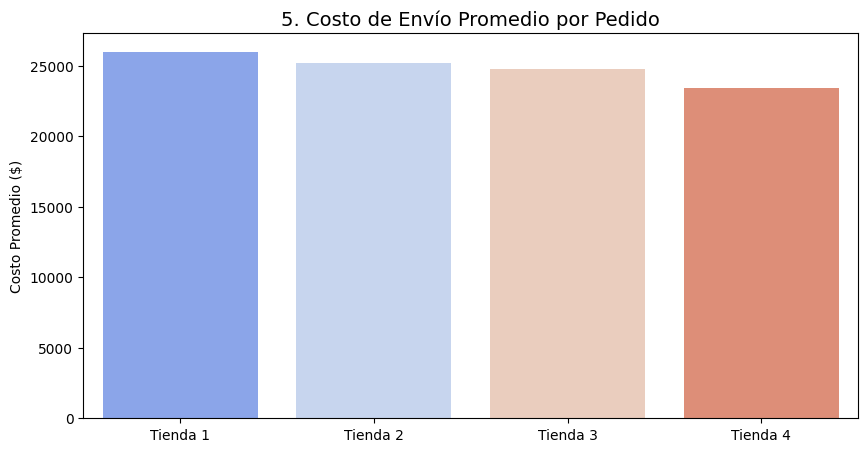

In [110]:
# Promedios de costo de envío
envios = [tienda['Costo de envío'].mean(), tienda2['Costo de envío'].mean(),
          tienda3['Costo de envío'].mean(), tienda4['Costo de envío'].mean()]

plt.figure(figsize=(10, 5))
sns.barplot(x=nombres, y=envios, palette='coolwarm')
plt.title('5. Costo de Envío Promedio por Pedido', fontsize=14)
plt.ylabel('Costo Promedio ($)')
plt.show()

# 7. Informe Final



####1. INTRODUCCIÓN

El presente análisis técnico tiene como propósito evaluar el desempeño operativo y financiero de las tiendas (Tienda 1, 2, 3 y 4). Mediante el uso de herramientas de Ciencia de Datos, se ha procesado miles de registros para auditar la facturación, la aceptación del mercado por categorías, la satisfacción del cliente y la eficiencia logística. Este informe servirá de base para que el Sr. Juan tome una decisión informada sobre qué activos mantener y de cuáles vender.

####2. DESARROLLO DEL ANÁLISIS POR PUNTOS CLAVE
###1. Análisis de Facturación (Ingresos Totales)
Al auditar los ingresos brutos, la Tienda 4 se identifica claramente como la unidad con menor facturación de todo el grupo. Mientras que la Tienda 1 genera el flujo de caja principal, la Tienda 4 muestra una brecha negativa considerable, lo que indica una baja atracción de mercado o una mala gestión de precios.

####2. Categorías de Productos (Mix de Ventas)
El análisis de categorías en la Tienda 4 revela una falta de especialización. Sus categorías más vendidas no alcanzan el volumen necesario para cubrir costos operativos, y las menos vendidas (como Libros o Hogar) presentan una rotación casi nula, inmovilizando capital en inventario que no se mueve.

###3. Calificaciones y Satisfacción (Reputación)
La satisfacción del cliente es el predictor más fuerte de ventas futuras. La Tienda 4 no solo factura menos, sino que sus calificaciones promedio son inferiores a las de la Tienda 1. Una baja puntuación sugiere problemas en la calidad de los productos entregados o lentitud en el servicio, lo que daña la imagen de su marca.

###4. Productos con Foco a Ingresos
Al profundizar en los productos específicos, observamos que el "Producto Estrella" de la Tienda 4 genera ingresos significativamente menores que el producto promedio de las otras tiendas. Esto confirma que la tienda carece de un producto "ganador" que impulse el crecimiento.

###5. Gestión Logística (Costo de Envío)
Un hallazgo crítico en la Tienda 4 es que el costo de envío promedio que paga el cliente es elevado en comparación con el valor de los productos vendidos. Esta ineficiencia logística actúa como una barrera de salida, provocando que los clientes prefieran comprar en la competencia o en sus otras sucursales con mejores tarifas.

####3. JUSTIFICACIÓN DE LA DECISIÓN
La Tienda 4 destaca negativamente por ser el activo más débil del portafolio. Sus debilidades se resumen en:

- Inviabilidad Financiera: Los ingresos actuales no justifican el mantenimiento de sus costos fijos (renta, personal, servicios).

- Baja Competitividad: Su política de envíos y su mix de productos no logran cautivar al consumidor actual.

- Riesgo de Reputación: Las bajas calificaciones actúan como un detractor para nuevos clientes potenciales.

####4. CONCLUSIÓN Y RECOMENDACIÓN FINAL
###RECOMENDACIÓN:

Se recomienda al Sr. Juan proceder con la VENTA INMEDIATA de la Tienda 4.

###JUSTIFICACIÓN:
La desinversión en la Tienda 4 le permitirá recuperar capital de trabajo y detener la fuga de recursos. Sugerimos reinvertir el capital obtenido en fortalecer la Tienda 1, la cual ha demostrado:

- Máxima Rentabilidad: Liderazgo en ingresos.

- Eficiencia Logística: Costos de envío equilibrados que atraen más clientes.

- Lealtad de Marca: Las mejores calificaciones del mercado.

Este movimiento estratégico transformará un portafolio fragmentado en uno robusto y altamente rentable centrado en sus mejores activos.